# Uses of DBSCAN

1. When clusteres are non-spherical 

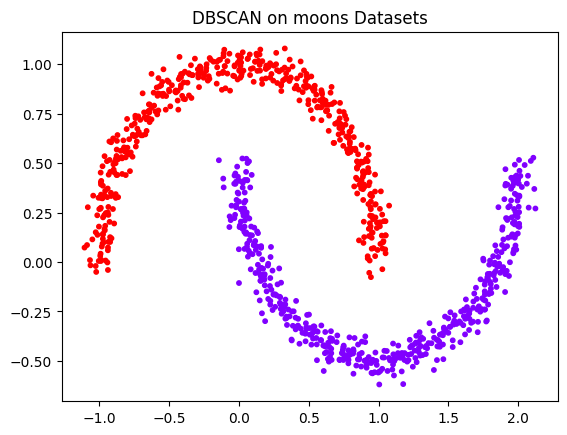

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

# Datasets 
X , y = make_moons(n_samples = 1000,  noise = 0.05, random_state = 42)

# DBSCAN
dbscan  = DBSCAN(eps = 0.2 , min_samples = 5)
labels =  dbscan.fit_predict(X)

#Plot
plt.scatter(X[:,0] , X[:,1] , c=labels , cmap='rainbow' , s= 10)
plt.title("DBSCAN on moons Datasets")
plt.show()

K-Means fails on the moons dataset because it partitions data using distance to centroids, producing linear boundaries that cannot separate non-convex clusters.

Observe

✔ Two moon-shaped clusters
✔ No need to specify k
✔ K-Means fails here

USE CASE 2: Outlier / Anomaly Detection

You want to detect noise automatically

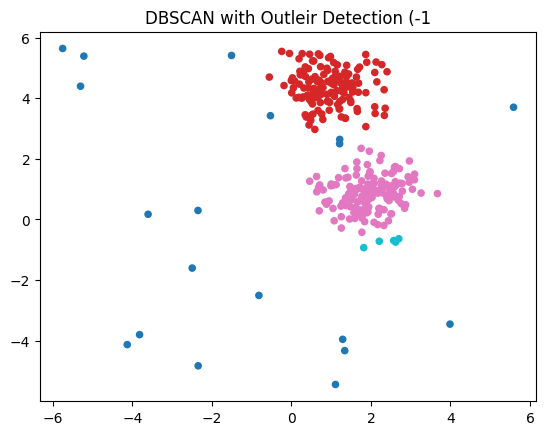

In [13]:
from sklearn.datasets import make_blobs
X , _ = make_blobs(n_samples =  300 , centers = 2 , cluster_std = 0.6 , random_state = 0)
# Add clusters
rng = np.random.RandomState(42)
outliers = rng.uniform(low = -6 , high =  6 , size=(20,2))
X =  np.vstack([X , outliers])
dbscan = DBSCAN(eps = 0.5 , min_samples =  5)
labels = dbscan.fit_predict(X)

# Plot 
plt.scatter(X[: , 0] , X[: , 1] , c = labels , cmap = 'tab10' , s = 20) 
plt.title("DBSCAN with Outleir Detection (-1")
plt.show()

🔍 Observe

✔ Outliers labeled as -1
✔ Clusters untouched
✔ Natural anomaly detection

🔹 USE CASE 3: Unknown Number of Clusters
When?

You don’t know how many clusters exist

Clusters found: 4


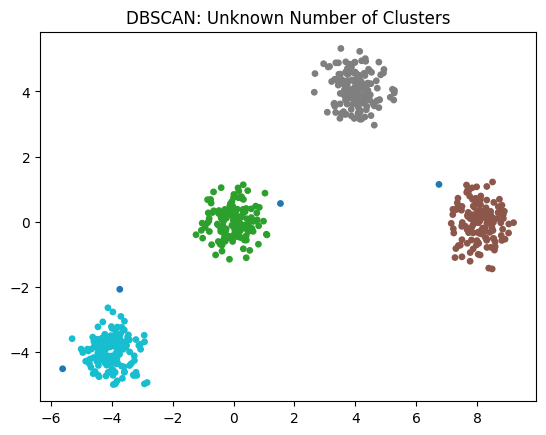

In [14]:
from sklearn.datasets import make_blobs

X, _ = make_blobs(
    n_samples=600,
    centers=[(-4,-4),(0,0),(4,4),(8,0)],
    cluster_std=0.5,
    random_state=42
)

dbscan = DBSCAN(eps=0.6, min_samples=5)
labels = dbscan.fit_predict(X)

# Number of clusters (excluding noise)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Clusters found:", n_clusters)

plt.scatter(X[:,0], X[:,1], c=labels, cmap='tab10', s=15)
plt.title("DBSCAN: Unknown Number of Clusters")
plt.show()


🔍 Observe

✔ DBSCAN finds clusters automatically
✔ No k required

After applying DBSCAN and identifying the number of clusters, the next step is to validate and interpret the clusters.
Cluster sizes and statistical properties are analyzed to understand their meaning.
Noise points can be removed to clean the dataset.
The discovered clusters can be used directly for exploratory analysis or as features for supervised learning.
A classifier may be trained on core points to enable prediction for new data.

🔹 USE CASE 4: Geospatial / Density-based grouping
When?

Clusters are based on physical closeness

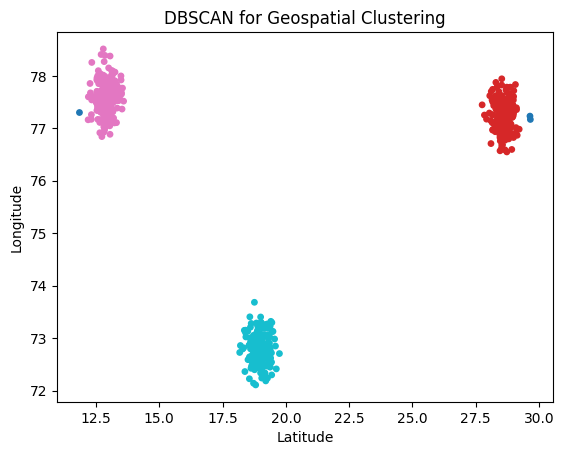

In [17]:
# Simulated GPS-like data
centers = [[28.6, 77.2], [19.0, 72.8], [12.9, 77.6]]  # Delhi, Mumbai, Bangalore
X, _ = make_blobs(n_samples=600, centers=centers, cluster_std=0.3)

dbscan = DBSCAN(eps=0.4, min_samples=10)
labels = dbscan.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels, cmap='tab10', s=15)
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("DBSCAN for Geospatial Clustering")
plt.show()


🔍 Observe

✔ Cluster based on density
✔ Suitable for location data
✔ Outliers appear naturally

labels = dbscan.fit_predict(X)

# Separate anomalies
anomalies = X[labels == -1]
clean_data = X[labels != -1]
After clustering using DBSCAN, the results are typically used for outlier detection, data cleaning, or exploratory analysis.
Noise points can be removed to improve downstream models.
Clusters can be analyzed to extract insights or used as additional features.
A classifier such as KNN can be trained on core points to assign new instances.
DBSCAN is often used as a preprocessing or analysis step rather than a final predictive model.